# Demonstration of motion correction of power doppler images

This notebook automate the process of visualize, detect, and correct in-plane/out-of-plane frames.

It will save the following files in the same folder as the defined output_path:
1) NIFTI nii.gz containing the corrected PD images
2) out-of-plane labels appended to probe_events.csv
3) Params of transformation and similarity metric to transformation.csv

In [3]:
%load_ext autoreload
%autoreload 2

import os
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
from gui import *
import image_utils
from pathlib import Path
from IPython.display import HTML, Video
from SessionLoader import SessionLoader

# import nilearn as nl
from nilearn import image
import nibabel as nib


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load NIFTI

In [85]:
#################################################################
#      Define data paths and choose output path location        #
#################################################################

save_output_on_local = True
base_path = '/Volumes/UCLA_collaboration/'
session_run = '2024-06-13/UCLA_006/run-09/'

# define output path to save data, plots, and videos (default: /fUSI_corrected)
if save_output_on_local:
    output_path = Path.home() / "Downloads" / "Data" / session_run  # save to user defined location e.g. (/Downloads folder)
else:
    # default to /fUSI_corrected within acqusition sequence in base_path (ses.sequence_data_path)
    output_path = None

#################################################################
#          Loading paths and choose acquisition sequence        #
#################################################################

# Find path using sessionLoader
ses = SessionLoader(base_path + session_run, sequence=None, output_path=output_path)
if ses.sequence_folders is not None:
    ses.load_acquisition_directories( sequence_index=0 ) # switch between sequences if there are multiple (default: 0)

Selected sequence in the acquisitions path:
--> 0. seq-RF_full_apert_5000000Hz_5a_3c_2rp_10Dmin_40Dmax_3el_TGC0ini_50end_8000Tdur_-1Gain_3AFE_200loops

Loaded directories:

 - log_file_path:       	/Volumes/UCLA_collaboration/2024-06-13/UCLA_006/run-09/logs/task_1.log
 - task_event_file_path:  	/Volumes/UCLA_collaboration/2024-06-13/UCLA_006/run-09/streams/task_1-event_stream.h5
 - probe_event_file_path: 	/Volumes/UCLA_collaboration/2024-06-13/UCLA_006/run-09/streams/probe_1-event_stream.h5
 - sequence_data_path:  	/Volumes/UCLA_collaboration/2024-06-13/UCLA_006/run-09/acquisitions/seq-RF_full_apert_5000000Hz_5a_3c_2rp_10Dmin_40Dmax_3el_TGC0ini_50end_8000Tdur_-1Gain_3AFE_200loops
 - raw_data_path:       	/Volumes/UCLA_collaboration/2024-06-13/UCLA_006/run-09/acquisitions/seq-RF_full_apert_5000000Hz_5a_3c_2rp_10Dmin_40Dmax_3el_TGC0ini_50end_8000Tdur_-1Gain_3AFE_200loops/raw_frame_data
 - beamformed_path:     	/Volumes/UCLA_collaboration/2024-06-13/UCLA_006/run-09/acquisitions/seq-RF_ful

In [86]:
# load NIFTI
filename='original.nii.gz'
fusi_data = ses.load_nifti(path_name=ses.output_path, filename=filename)

Loaded power doppler images stored in NIFTI. Shape: (274, 2, 252, 102)
Loaded metadata from metadata.json.
Loaded probe_events from probe_events.csv.


In [87]:
################################################
#           Display Power Doppler movie        #
################################################
Video(output_path /'pd.mp4', embed=True)

Outlier frames more than 500.0 from median:  [101]


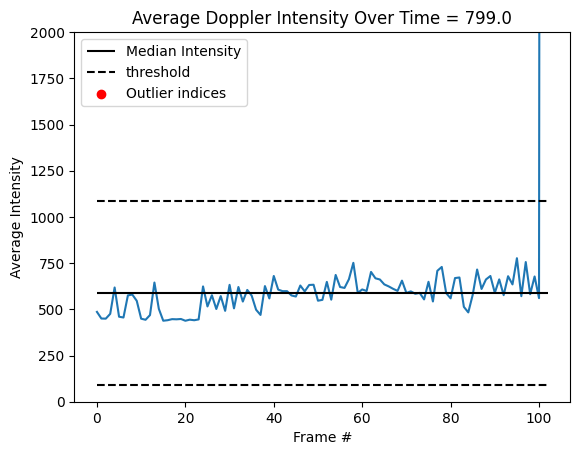

In [89]:
################################################
#     Display Doppler intensity time course    #
################################################
outlier_threshold = 500

doppler_intensity_per_frame, outlier_intensity_frames = \
    image_utils.plot_pd_intensity_over_time(fusi_data, 
                                            y_lim=[0, 2000],
                                            outlier_threshold=outlier_threshold)

# Identify out-of-plane images

After PCA shape: (102, 100)
Explain variance sum of top 100 components: 100.0%


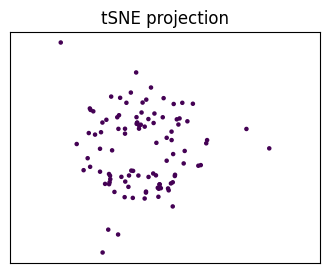

In [101]:
#############################################################################
#                  identify any out-of-plan images                          #
#############################################################################

from sklearn.decomposition import PCA

use_thresholded_mask = False
dim_red_method = 'tSNE' # PCA or 'UMAP' or 'tSNE'
pca_n_components = 100
perplexity = min(200, ses.n_frames - 1)

# use the thresholded images 
el = 0
if use_thresholded_mask:
    disp_image_index = np.arange(82,102)
    threshold_imgs, density = image_utils.get_threshold_image(fusi_data[:, el], threshold=0.5)
    print('Applied binary masking to get thresholded images')
    image_utils.show_imgs(threshold_imgs, disp_image_index, fig_height=1.1)
    imgs_flatten = threshold_imgs.reshape(-1, threshold_imgs.shape[-1]).T
else:
    imgs_flatten = fusi_data.reshape(-1, fusi_data.shape[-1]).T

pca=PCA(n_components=pca_n_components)

# Reduce number of dimension
lowd = pca.fit_transform(imgs_flatten)
print(f'After PCA shape: {lowd.shape}')
explained_variance = pca.explained_variance_ratio_
print(f'Explain variance sum of top {pca_n_components} components: {sum(explained_variance).round(3)*100}%')
concat_lowd_intensity = np.concatenate([lowd, doppler_intensity_per_frame.reshape(-1,1)], axis=-1)

if dim_red_method == 'PCA':
    ### Visualize with PCA
    embedding = lowd[:,:2]
elif dim_red_method == 'UMAP':
    import umap
    ### Visualize with UMAP
    reducer = umap.UMAP(random_state=42, metric='cosine')
    embedding = reducer.fit_transform(lowd)
elif dim_red_method == 'tSNE':
    from sklearn.manifold import TSNE
    ### Visualize with tSNE
    tsne = TSNE(n_components=2, verbose=0, perplexity=perplexity, max_iter=300, random_state=42)
    embedding = tsne.fit_transform(lowd)

# Visualize top 2 embedding space
oop_labels = np.zeros((fusi_data.shape[-1], ), dtype=np.int32)
image_utils.plot_embedding(embedding, oop_labels, title=dim_red_method + ' projection', legend='off')

## Use DBSCAN for clustering planes
DBSCAN (Density-Based Spatial Clustering of Applications with Noise): This algorithm excels at finding clusters of various shapes and identifying outliers. It focuses on data point density, grouping points close together in high-density regions and separating them from areas with lower density. 

DBSCAN only requires two parameters: 
- a distance threshold (`epsilon`) 
- a minimum number of points in a cluster (`min_samples`). 

It's robust to outliers and doesn't require pre-defining the number of clusters, making it a good choice for exploratory data analysis.

See more: https://scikit-learn.org/stable/auto_examples/cluster/plot_dbscan.html#sphx-glr-auto-examples-cluster-plot-dbscan-py

In [105]:
from sklearn.cluster import DBSCAN

eps = .5 # smaller eps, more clusters

db = DBSCAN(eps=eps).fit(embedding)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

# print original labels 20 in a row
print('\n Clustering labels original:')
for row in range(len(labels) // 20 + 1):
    print(row*20, '\t', labels[row * 20:(row + 1) * 20])

Estimated number of clusters: 1
Estimated number of noise points: 0

 Clustering labels original:
0 	 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
20 	 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
40 	 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
60 	 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
80 	 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
100 	 [0 0]


## Relabel cluster number to match with our label convention
The output of kmean clusters are integers in ascending orders, and clusters are unassigned to the label class as described below. Hence, we are mapping kmean labels to match with our convention used in manual labeling.

**0** means in-plane, \
**-1** means out-of-plane and should be skipped, \
**i** (integer > 0) means new out-of-plane but should be included as new plane stacks.

Percentage of frames that are also doppler intensity outliers:  99.01960784313725

Remapped predicted labels:
0 	 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
20 	 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
40 	 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
60 	 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
80 	 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
100 	 [ 0 -1]

Summary of consecutive counts for each class:
0.0: [101]
-1.0: [1]
% of out-of-plane frames: 0.98%


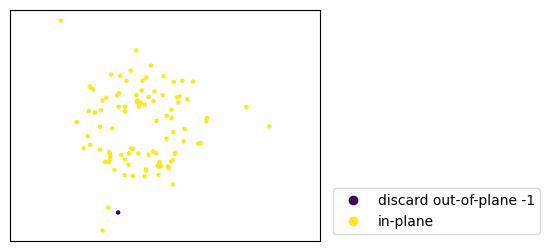

In [108]:
pred_labels,_ = image_utils.remap_cluster_to_labels(labels)

# combine with outlier_intensity_frames
# check percentage that pred_labels are equal to outlier_intensity_frames
print('Percentage of frames that are also doppler intensity outliers: ', \
      100*np.sum((pred_labels < 0) == outlier_intensity_frames)/len(outlier_intensity_frames))

pred_labels[outlier_intensity_frames] = -1

# print predicted labels 20 in a row
print('\nRemapped predicted labels:')
for row in range(len(pred_labels) // 20 + 1):
    print(row*20, '\t', pred_labels[row * 20:(row + 1) * 20])

# Get the counts of consecutive labels
summary_count = image_utils.get_consecutive_labels_counts(pred_labels)

print('\nSummary of consecutive counts for each class:')
for key in summary_count.keys():
    print(f'{key}: {summary_count[key]}')

# Visualize new clustering on predicted labels
image_utils.plot_embedding(embedding, pred_labels)

# out-of-plane frame indices
oop_labels = pred_labels
oop_indices = np.where(np.array(oop_labels) < 0)[0]
in_plane_indices = np.where(np.array(oop_labels) == 0)[0]

print(f'% of out-of-plane frames: {len(oop_indices)/len(oop_labels)*100:.2f}%')

# get the range of oop start stops for plotting
oop_labels_pad = np.pad(oop_labels, (1, 1), 'constant', constant_values=(0, 0))
range_oop = [i for i in range(len(oop_labels_pad)-1) if oop_labels_pad[i+1] - oop_labels_pad[i] != 0]
if len(range_oop) == 1:
    range_oop.append(len(oop_labels)) # append last index at the end

,label,count,centroid,ref_frame
0,0.0,[101],"[-0.4272308051586151, 0.3142135739326477]",42


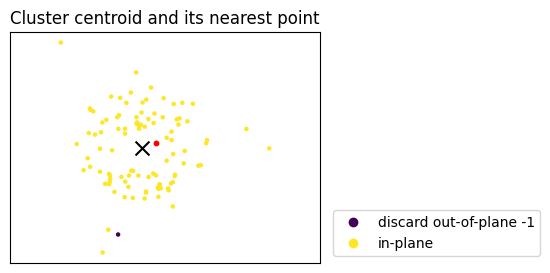

In [122]:
# Find nearest point to the centroid of the clusters
from sklearn.metrics import pairwise_distances_argmin_min
import pandas as pd

labels_df = pd.DataFrame(summary_count.items(), columns=['label', 'count'])
labels_df = labels_df.loc[labels_df['label'].values != -1.0]
centroids = np.zeros((len(labels_df), embedding.shape[-1]))
ref_frame_per_cluster = np.zeros((len(labels_df),1), dtype=int)
for i, label_key in enumerate(labels_df['label']):
    cluster_indices = np.where(pred_labels == label_key)[0]
    centroids[i]  = np.mean(embedding[cluster_indices], axis=0)
    closest_point, _ = pairwise_distances_argmin_min(centroids[i].reshape(1,-1), embedding[cluster_indices])
    ref_frame_per_cluster[i] = cluster_indices[closest_point[0]]
labels_df['centroid'] = centroids.tolist()

image_utils.plot_embedding(embedding, pred_labels, centroids=centroids, title='Cluster centroid and its nearest point at index')
# label the nearest point to the centroid in the embedding space
for i, centroid in enumerate(centroids):
    plt.scatter(embedding[ref_frame_per_cluster[i], 0], embedding[ref_frame_per_cluster[i], 1], s=10, c='red', label='Frame closest to centroid')
plt.savefig(output_path / 'cluster_nearest_points.png', dpi=400, bbox_inches='tight')
labels_df['ref_frame'] = ref_frame_per_cluster
labels_df

In [124]:
ses.probe_events['out_of_plane_labels'] = pred_labels
ses.probe_events

,Event,raw_file_name,acquisition_idx,time_stamp,fusi_file_name,full_path,out_of_plane_labels
index,,,,,,,
0,ensemble_saved,ensemble_2024-06-13T20-32-17-674690.h5,0,3.717761,ensemble_2024-06-13T20-32-17-674690-pixel_size...,/Volumes/UCLA_collaboration/2024-06-13/UCLA_00...,0
1,ensemble_saved,ensemble_2024-06-13T20-32-19-886605.h5,1,5.982721,ensemble_2024-06-13T20-32-19-886605-pixel_size...,/Volumes/UCLA_collaboration/2024-06-13/UCLA_00...,0
2,ensemble_saved,ensemble_2024-06-13T20-32-21-780620.h5,2,7.839267,ensemble_2024-06-13T20-32-21-780620-pixel_size...,/Volumes/UCLA_collaboration/2024-06-13/UCLA_00...,0
3,ensemble_saved,ensemble_2024-06-13T20-32-23-635804.h5,3,9.686882,ensemble_2024-06-13T20-32-23-635804-pixel_size...,/Volumes/UCLA_collaboration/2024-06-13/UCLA_00...,0
4,ensemble_saved,ensemble_2024-06-13T20-32-25-498507.h5,4,11.556757,ensemble_2024-06-13T20-32-25-498507-pixel_size...,/Volumes/UCLA_collaboration/2024-06-13/UCLA_00...,0
...,...,...,...,...,...,...,...
97,ensemble_saved,ensemble_2024-06-13T20-35-21-367155.h5,97,187.459012,ensemble_2024-06-13T20-35-21-367155-pixel_size...,/Volumes/UCLA_collaboration/2024-06-13/UCLA_00...,0
98,ensemble_saved,ensemble_2024-06-13T20-35-23-283368.h5,98,189.521969,ensemble_2024-06-13T20-35-23-283368-pixel_size...,/Volumes/UCLA_collaboration/2024-06-13/UCLA_00...,0
99,ensemble_saved,ensemble_2024-06-13T20-35-25-379937.h5,99,191.486055,ensemble_2024-06-13T20-35-25-379937-pixel_size...,/Volumes/UCLA_collaboration/2024-06-13/UCLA_00...,0


# Perform image registration on in-plane frame indices

Reference frame for registration is: 42
Registered images shape: (274, 252, 101)
Registered images shape:  (274, 1, 252, 101)


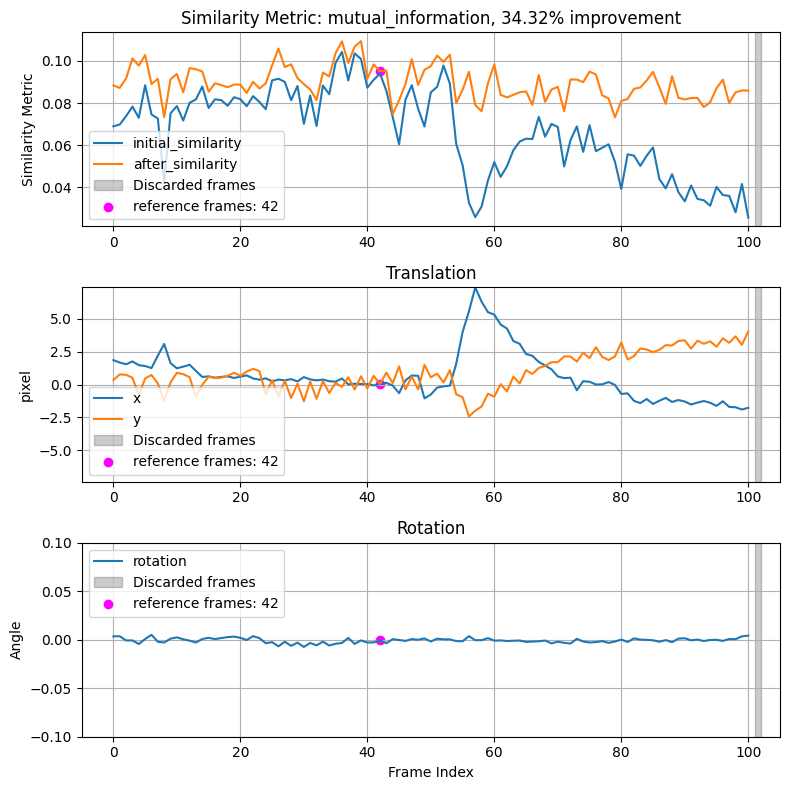

In [128]:
#############################################################################
# If needed: perform image registration and display transformation dynamic  #
#############################################################################

# register only in-plane images
use_thresholded_mask = False
use_centroid_as_ref_frame = True
metric_name = 'mutual_information'

if use_thresholded_mask:
    data, density = image_utils.get_threshold_image(fusi_data[:, el], threshold=0.5)
else:
    data = fusi_data[:, el]
data_selected = data[:, :, in_plane_indices]


if use_centroid_as_ref_frame:
    ref_frame = labels_df.loc[labels_df['label'].values == 0.0, "ref_frame"].values.astype(int)[0]
else:
    ref_frame = 0

# use image nearest to centroid as the reference frame
print(f'Reference frame for registration is: {ref_frame}')

# register the images
registered_images, extra = image_utils.register_ants(data_selected, ref_index=ref_frame)
print('Registered images shape: ', registered_images.shape)

image_utils.plot_transform_params(extra, range_oop=range_oop, metric_name=metric_name, annotate_ref_frame=ref_frame)

# TO DO: if use_thresholded_mask: apply transform param to fusi data 

plt.savefig(output_path / 'transform_params.png', dpi=400, bbox_inches='tight')

In [126]:
# save the registered images to a gif or a mp4
ani = MakeAnimation(registered_images[:,0], 
                    output_file=str(output_path /'registered_pd.gif'), 
                    fps=10, 
                    depth=ses.metadata['depth'][crop_border:-crop_border], 
                    lateral=ses.metadata['lateral'][crop_border:-crop_border], 
                    time=ses.metadata['time'],
                    )
HTML(ani.to_jshtml())

ses.save_to_nifti(registered_images, filename='registered_pd.nii.gz')


Saved PD NIFTI as registered_pd.nii.gz
Saved metadata as metadata.json.
Saved probe events as probe_events.csv.
Output location: /Users/ewina/Downloads/Data/2024-06-13/UCLA_006/run-09


PosixPath('/Users/ewina/Downloads/Data/2024-06-13/UCLA_006/run-09/registered_pd.nii.gz')

In [127]:
extra.to_csv(output_path / 'transform_extra.csv', index=True, index_label='index')
